## Setup

In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))
print(f"Project root: {ROOT}")

Project root: /Users/ratamate/Documents/Project Pribadi/Project Akhir - DIbimbing copy


In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# from src.utils.geo import haversine_vectorized

clean_path = ROOT / 'data' / 'clean'
processed_path = ROOT / 'data' / 'processed'
processed_path.mkdir(parents=True, exist_ok=True)

## Load Cleaned Data

In [3]:
df_cafe = pd.read_csv(clean_path / 'cafes_clean.csv')
df_owner = pd.read_csv(clean_path / 'owner_clean.csv')

poi = {}
for cat in ['office', 'mall', 'transit', 'school']:
    f = clean_path / f'osm_{cat}_clean.csv'
    poi[cat] = pd.read_csv(f)
    print(f"poi {cat:8s}: {len(poi[cat])}")


print(f"Cafes:  {len(df_cafe)}")
print(f"Owner:  {len(df_owner)}")

poi office  : 3782
poi mall    : 637
poi transit : 4627
poi school  : 6387
Cafes:  1843
Owner:  16


## Feature Extraction Functions

In [4]:
def haversine(lat1, lng1, lat2, lng2):
    """Jarak meter antara 2 lat/lng."""
    R = 6371000
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp = math.radians(lat2 - lat1)
    dl = math.radians(lng2 - lng1)
    a = math.sin(dp / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dl / 2) ** 2
    return 2 * R * math.asin(math.sqrt(a))


def haversine_vectorized(lat1, lng1, lats, lngs):
    """Vectorized haversine pakai numpy."""
    R = 6371000
    p1 = math.radians(lat1)
    p2 = np.radians(lats)
    dp = np.radians(lats - lat1)
    dl = np.radians(lngs - lng1)
    a = np.sin(dp / 2) ** 2 + math.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

In [5]:
def count_radius(lat, lng, df, max_radius):
    hv = haversine_vectorized(lat, lng, df['lat'], df['lng'])
    filter_radius = (hv < max_radius)
    n_store = filter_radius.sum()

    return int(n_store)


def competitor_count(lat, lng, data_cafe, id, max_radius):
    others = data_cafe[data_cafe['place_id'] != id]

    d = haversine_vectorized(lat, lng, others['lat'].values, others['lng'].values)

    subset = others[d < max_radius]

    results = {
        'place_id': id,
        'n_comp': int(len(subset)),
        'avg_rating': round(subset['rating'].mean(),1) if len(subset) else 0,
        'total_reviews': int(subset['reviews_count'].sum()) if len(subset) else 0,
        'max_reviews': int(subset['reviews_count'].max()) if len(subset) else 0
    }

    return results

def nearest_owner(lat, lng):
    d_owner = haversine_vectorized(
        lat, lng,
        df_owner["lat"].values, df_owner["lng"].values
    )
    
    if len(d_owner) > 0:
        nearest_owner = float(d_owner.min())
    else:
        None
    
    return nearest_owner


def extract_features(lat, lng, id=None):
    n_comp_500 = competitor_count(lat, lng, df_cafe, id, 500)
    n_comp_2km = competitor_count(lat, lng, df_cafe, id, 2000)
           
    results = {
        "n_competitors_500m": n_comp_500["n_comp"],
        "avg_competitor_rating_500": n_comp_500["avg_rating"],
        "total_competitor_reviews_500": n_comp_500["total_reviews"],
        "max_competitor_reviews_500": n_comp_500["max_reviews"],
        "n_competitors_2km": n_comp_2km["n_comp"],
        "avg_competitor_rating_2km": n_comp_2km["avg_rating"],
        "total_competitor_reviews_2km": n_comp_2km["total_reviews"],
        "max_competitor_reviews_2km": n_comp_2km["max_reviews"],
        "nearest_owner_store_m": round(nearest_owner(lat, lng),2),
        "n_offices_500m": count_radius(lat, lng, poi["office"], 500),
        "n_offices_2km": count_radius(lat, lng, poi["office"], 2000),
        "n_malls_500m": count_radius(lat, lng, poi["mall"], 500),
        "n_malls_2km": count_radius(lat, lng, poi["mall"], 2000),
        "n_transit_500m": count_radius(lat, lng, poi["transit"], 500),
        "n_transit_2km": count_radius(lat, lng, poi["transit"], 2000),
        "n_schools_500m": count_radius(lat, lng, poi["school"], 500),
        "n_schools_2km": count_radius(lat, lng, poi["school"], 2000),
    }

    return results

## Build Training Dataset

In [6]:
# Detect ID column name
id_col = None
for c in ['place_id', 'id', 'osm_id']:
    if c in df_cafe.columns:
        id_col = c
        break

rows = []
for _, cafe in tqdm(df_cafe.iterrows(), total=len(df_cafe), desc='Extracting features'):
    id = cafe[id_col] if id_col else None
    feats = extract_features(cafe['lat'], cafe['lng'], id=id)
    
    # Add target + metadata
    feats['target'] = cafe['rating'] * np.log1p(cafe['reviews_count'])
    feats['cafe_id'] = id
    feats['cafe_name'] = cafe.get('name', '')
    feats['lat'] = cafe['lat']
    feats['lng'] = cafe['lng']
    feats['rating_cafe'] = cafe['rating']
    feats['reviews_count_cafe'] = cafe['reviews_count']
    feats['kecamatan'] = cafe.get('kecamatan', '')
    feats['kota'] = cafe.get('kota', '')
    
    rows.append(feats)

df_features = pd.DataFrame(rows)
print(f"\n✓ Training dataset: {df_features.shape}")
df_features.head()

Extracting features: 100%|██████████| 1843/1843 [00:09<00:00, 191.11it/s]


✓ Training dataset: (1843, 26)


,n_competitors_500m,avg_competitor_rating_500,total_competitor_reviews_500,max_competitor_reviews_500,n_competitors_2km,avg_competitor_rating_2km,total_competitor_reviews_2km,max_competitor_reviews_2km,nearest_owner_store_m,n_offices_500m,...,n_schools_2km,target,cafe_id,cafe_name,lat,lng,rating_cafe,reviews_count_cafe,kecamatan,kota
0,7,4.2,3259,2361,97,4.6,78027,6181,2118.00,24,...,115,27.856419,ChIJk2S-5gT1aS4R7BfG9zPTqeg,Stroom Coffee,-6.180408,106.832789,4.5,487,Gambir,Jakarta Pusat
1,5,4.8,5481,5032,95,4.6,51215,5032,2531.54,20,...,100,40.221468,ChIJM-y5dv_3aS4Ru5vfq9j1HK4,Kopi Nako,-6.172734,106.821282,4.7,5206,Gambir,Jakarta Pusat
2,5,4.7,1314,817,105,4.6,53272,5206,2984.80,16,...,115,32.193144,ChIJ_YWVAtP1aS4RP0dLZugFvDg,21 Factory Gelato & Coffee,-6.170070,106.829746,4.6,1094,Gambir,Jakarta Pusat
3,2,4.6,842,691,78,4.7,30902,5206,3243.30,17,...,126,29.160201,ChIJGRmYnyj3aS4RBrjMwAep-HE,9 GRAMS,-6.167211,106.813952,4.5,651,Gambir,Jakarta Pusat
4,10,4.2,3605,2361,113,4.6,78070,6181,2247.20,15,...,106,24.433022,ChIJp8FIVeL1aS4RTQt9O2sb8Gg,Loko Cafe Gambir,-6.177873,106.831042,4.4,257,Gambir,Jakarta Pusat


## EDA

### Distribusi Data

In [7]:
feature_cols = df_features.drop(columns=['cafe_id', 'cafe_name', 'kecamatan', 'kota', 'lat', 'lng']).columns.tolist()

# Summary stats
df_features[feature_cols].describe().round(2)

,n_competitors_500m,avg_competitor_rating_500,total_competitor_reviews_500,max_competitor_reviews_500,n_competitors_2km,avg_competitor_rating_2km,total_competitor_reviews_2km,max_competitor_reviews_2km,nearest_owner_store_m,n_offices_500m,n_offices_2km,n_malls_500m,n_malls_2km,n_transit_500m,n_transit_2km,n_schools_500m,n_schools_2km,target,rating_cafe,reviews_count_cafe
count,1843.00,1843.00,1843.00,1843.00,1843.00,1843.00,1843.00,1843.00,1843.00,1843.00,1843.00,1843.00,1843.00,1843.00,1843.00,1843.00,1843.00,1843.00,1843.00,1843.00
mean,6.88,4.28,2517.14,1133.87,55.59,4.67,23173.08,3497.43,3942.01,7.32,105.91,1.08,11.44,8.03,106.07,9.63,136.83,22.24,4.67,423.30
std,5.68,1.30,3768.95,1474.94,29.39,0.12,20059.18,2130.92,1868.84,6.53,75.83,2.08,9.21,6.04,50.75,5.80,50.26,7.86,0.27,858.01
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,92.94,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,2.75,2.10,1.00
25%,2.00,4.60,395.50,190.00,33.00,4.60,8640.50,1750.00,2551.24,3.00,46.00,0.00,4.00,3.00,73.00,5.00,103.00,16.98,4.50,37.00
50%,6.00,4.70,1161.00,596.00,52.00,4.70,17141.00,3300.00,4080.23,5.00,83.00,0.00,9.00,8.00,110.00,9.00,135.00,22.34,4.70,123.00
75%,10.00,4.80,3067.00,1389.50,73.00,4.70,28864.00,5206.00,5172.04,10.00,152.50,1.00,17.00,12.00,136.00,13.00,172.00,27.79,4.90,412.00
max,28.00,5.00,25161.00,7853.00,128.00,5.00,93547.00,8657.00,9090.83,38.00,313.00,14.00,49.00,30.00,250.00,32.00,272.00,43.21,5.00,8657.00


In [8]:
import matplotlib.pyplot as plt
import math

def plot_histograms(df, columns=None, bins=30, figsize=(15, 12)):
    if columns is None:
        columns = df.select_dtypes(include='number').columns.tolist()

    n_cols = 3
    n_rows = math.ceil(len(columns) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=figsize
    )

    axes = axes.flatten()

    for i, col in enumerate(columns):
        if 'target' in col:
            df[col].hist(bins=bins, ax=axes[i], color='orange', edgecolor='white')
            axes[i].set_title('TARGET')
        else:
            df[col].hist(bins=bins, ax=axes[i], color='steelblue', edgecolor='white')
            axes[i].set_title(col)

        # Applied to all columns, including target
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Frequency')

    # Hapus subplot kosong
    for j in range(len(columns), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

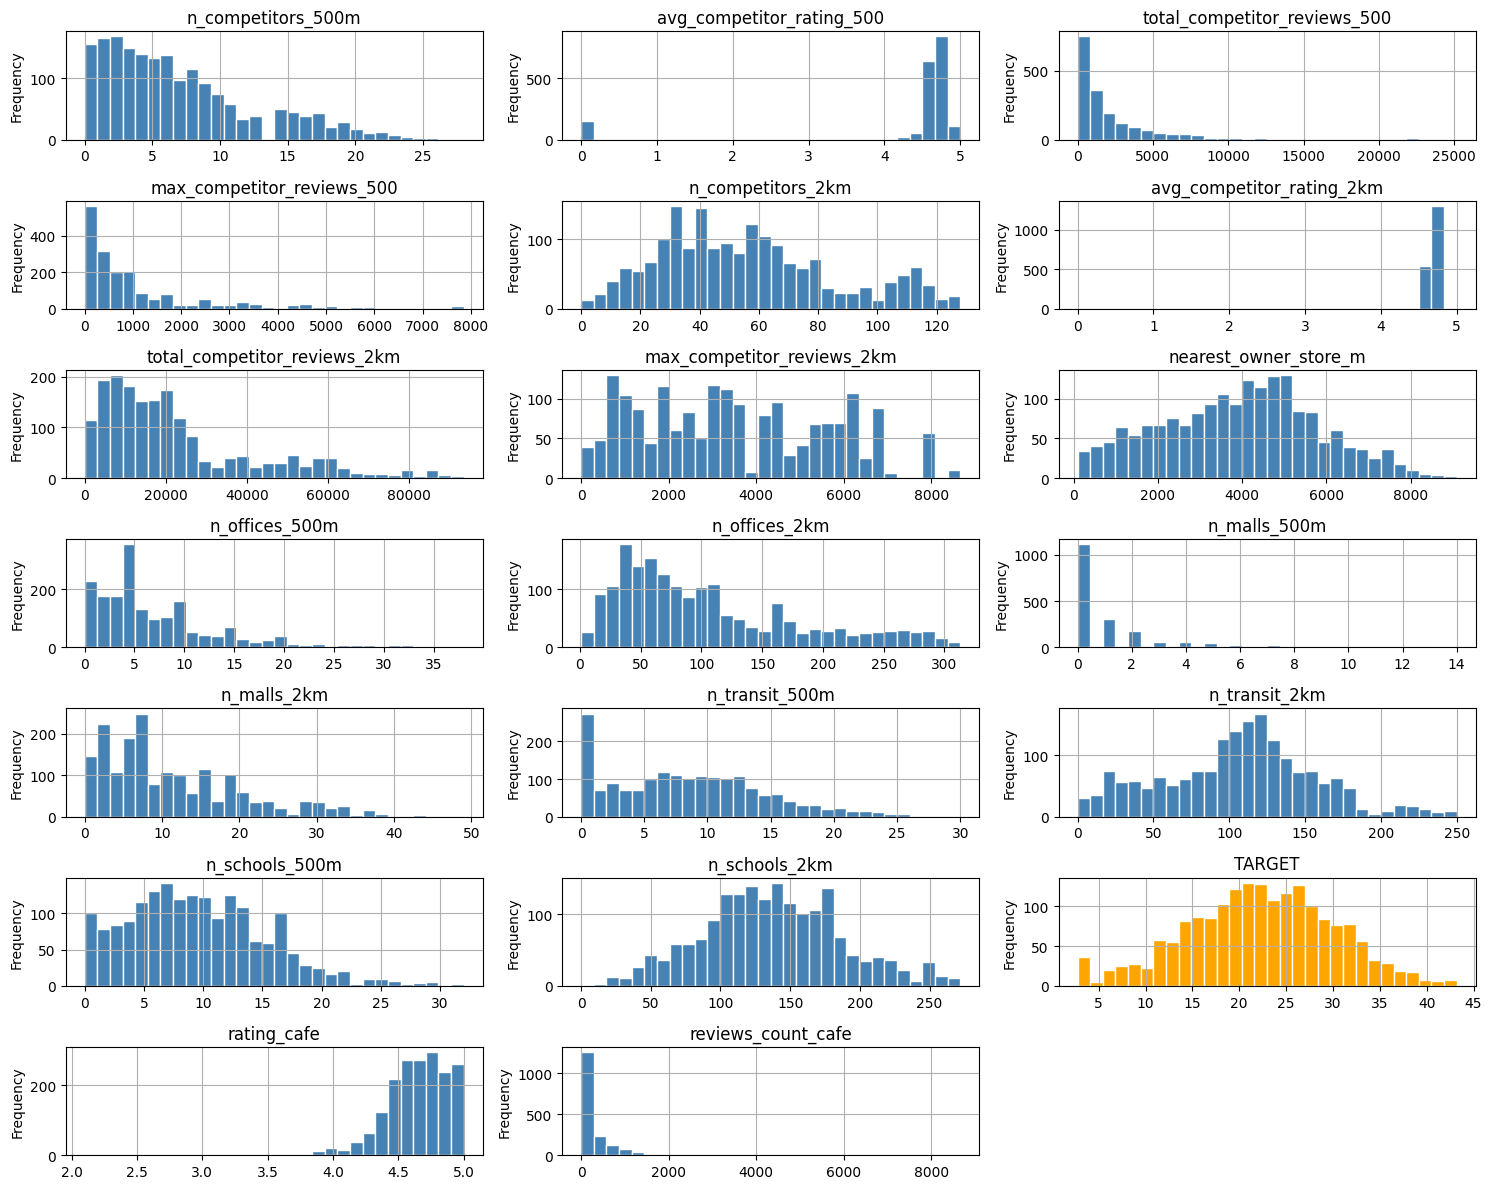

In [9]:
plot_histograms(df_features, feature_cols)

### Korelasi Feature dan Target

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_correlation_matrix(df, columns=None, figsize=(12, 8)):
    """
    Menampilkan heatmap korelasi antar kolom numerik.

    Parameters
    ----------
    df : pd.DataFrame
    columns : list, optional
        Kolom yang ingin dihitung korelasinya.
        Jika None, gunakan semua kolom numerik.
    figsize : tuple
        Ukuran figure.
    """

    if columns is None:
        corr = df.select_dtypes(include='number').corr()
    else:
        corr = df[columns].corr()

    plt.figure(figsize=figsize)
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0
    )

    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()

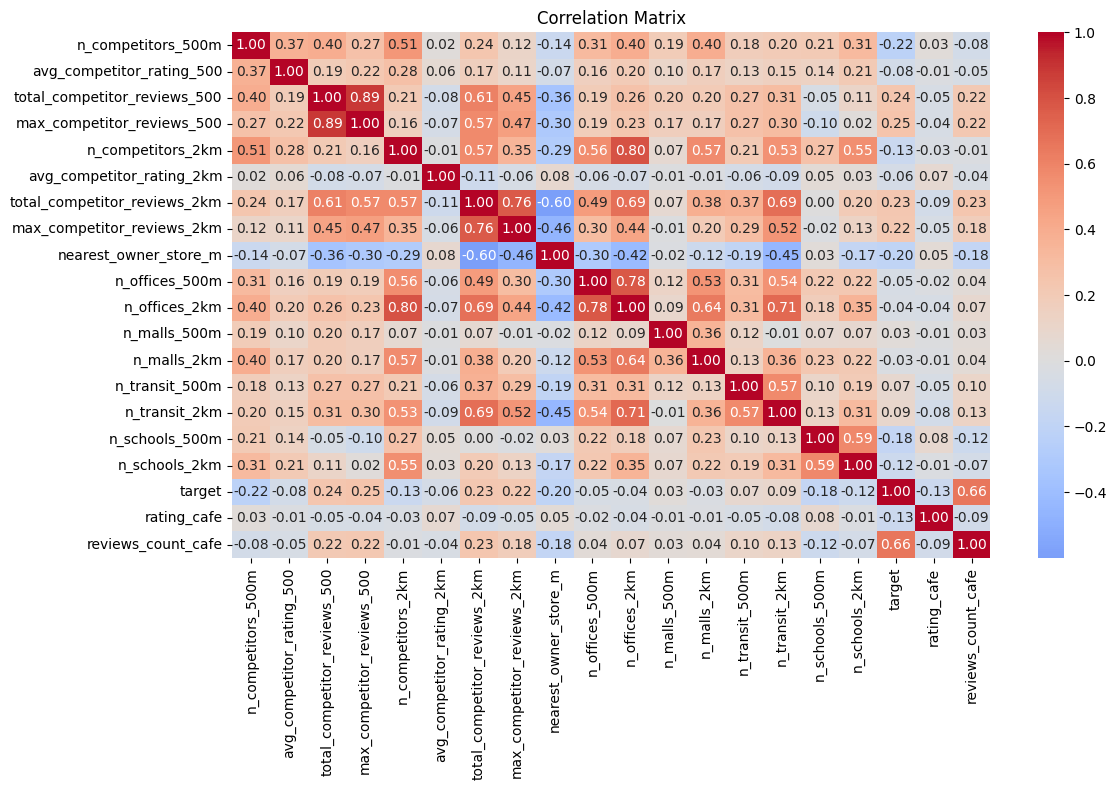

In [11]:
plot_correlation_matrix(df_features, feature_cols)

### Kecamatan Analysis

In [12]:
if 'kecamatan' in df_features.columns:
    kec_stats = df_features.groupby('kecamatan').agg(
        n_cafe=('cafe_id', 'count'),
        avg_rating=('rating_cafe', 'mean'),
        avg_target=('target', 'mean'),
        avg_offices_500m=('n_offices_500m', 'mean'),
    ).round(2).sort_values('avg_target', ascending=False).head(15)

kec_stats_df = kec_stats.copy()
kec_stats_df

,n_cafe,avg_rating,avg_target,avg_offices_500m
kecamatan,,,,
Menteng,44,4.62,30.97,14.30
Tebet,48,4.55,29.54,6.88
Kebayoran Baru,36,4.68,29.09,6.44
Kelapa Gading,46,4.73,28.54,4.35
Grogol Petamburan,46,4.66,27.34,9.43
Cilandak,48,4.68,26.41,3.81
Kebayoran Lama,43,4.68,25.65,4.86
Kembangan,43,4.62,25.09,2.65
Pulogadung,45,4.68,24.87,5.29


### Cafe dengan Target Tertinggi

In [13]:
print("Top 10 cafe by target:")
top10 = df_features.nlargest(10, 'target')[
    ['cafe_name', 'rating_cafe', 'reviews_count_cafe', 'kecamatan', 'target', 'n_offices_500m']
].reset_index(drop=True)

top10

Top 10 cafe by target:


,cafe_name,rating_cafe,reviews_count_cafe,kecamatan,target,n_offices_500m
0,Monggo Mampir (Kostel & Cafe),4.9,6752,Grogol Petamburan,43.206936,11
1,Teras Rumah Nenek,4.8,7016,Duren Sawit,42.509237,2
2,The People's Cafe - Central Park,4.9,5752,Grogol Petamburan,42.421636,23
3,Agreya Coffee - Duren Sawit,4.8,6820,Duren Sawit,42.373255,2
4,Tanatap Coffee Ampera,4.8,6548,Pasar Minggu,42.177925,3
5,Bakerzin Central Park,4.9,5358,Grogol Petamburan,42.074010,27
6,Tanatap Coffee Matraman,4.9,5166,Matraman,41.895233,10
7,Agreya Coffee Menteng,4.9,5073,Menteng,41.806235,5
8,Loffee Coffee & Eatery,4.8,5963,Tebet,41.728784,3
9,Satu Meja,4.9,4915,Cengkareng,41.651227,5


### Save Training Dataset

In [14]:
out = processed_path / 'features.csv'
df_features.to_csv(out, index=False)
print(f"Saved: {out}")
print(f"Shape: {df_features.shape}")
print(f"Columns: {list(df_features.columns)}")

Saved: /Users/ratamate/Documents/Project Pribadi/Project Akhir - DIbimbing copy/data/processed/features.csv
Shape: (1843, 26)
Columns: ['n_competitors_500m', 'avg_competitor_rating_500', 'total_competitor_reviews_500', 'max_competitor_reviews_500', 'n_competitors_2km', 'avg_competitor_rating_2km', 'total_competitor_reviews_2km', 'max_competitor_reviews_2km', 'nearest_owner_store_m', 'n_offices_500m', 'n_offices_2km', 'n_malls_500m', 'n_malls_2km', 'n_transit_500m', 'n_transit_2km', 'n_schools_500m', 'n_schools_2km', 'target', 'cafe_id', 'cafe_name', 'lat', 'lng', 'rating_cafe', 'reviews_count_cafe', 'kecamatan', 'kota']
